# MCDI500 — Programación para la Ciencia de Datos
## Fase 1: Definición del problema y configuración del entorno

**Proyecto:** PROYECTO-GRUPO4-MCDI500  
**Integrantes:**
- Carolina Cortés Donoso
- Pedro Espinoza Vicentela
- Marcelo Corro Troncoso
- Juan Pablo Valdebenito Loyola

**Docente:** Omar Iván Salinas Silva  
**Fecha:** Junio 2026

---
## 1. Contextualización del problema

El cáncer de mama es una de las principales causas de muerte oncológica en mujeres a nivel mundial. Según la Organización Mundial de la Salud (OMS), en 2022 se diagnosticaron aproximadamente 2,3 millones de nuevos casos y cerca de 670.000 mujeres fallecieron por esta enfermedad.

Dado que los principales factores de riesgo (género femenino, edad mayor a 40 años) no pueden ser controlados, la detección temprana se convierte en la estrategia más efectiva para reducir la mortalidad. En este contexto, el análisis de datos y las técnicas de aprendizaje automático ofrecen una oportunidad para apoyar el diagnóstico médico identificando patrones morfológicos asociados a tumores malignos.

### Pregunta central de investigación

> **¿Es posible predecir de manera precisa si un tumor mamario es benigno o maligno utilizando únicamente características morfológicas celulares?**

---
## 2. Objetivos del proyecto

### Objetivo general
Desarrollar y evaluar modelos de aprendizaje automático que permitan clasificar tumores mamarios como benignos o malignos a partir de características morfológicas celulares, identificando los factores de mayor influencia en la clasificación.

### Objetivos específicos
1. Comprender la estructura y características del dataset Breast Cancer Wisconsin (Diagnostic).
2. Configurar un entorno de trabajo reproducible con las herramientas del ecosistema científico de Python.
3. Realizar la limpieza, transformación y análisis exploratorio de los datos (F2).
4. Entrenar y comparar modelos de clasificación supervisada: Regresión Logística y Random Forest (F3).
5. Evaluar el desempeño de los modelos mediante métricas apropiadas e interpretar los resultados (F3).

### Alcance
**Incluye:** obtención y comprensión del dataset, limpieza y preparación de datos, análisis exploratorio, entrenamiento y evaluación de modelos, comparación de algoritmos, visualización de métricas.  
**No incluye:** uso clínico real del modelo, diagnóstico médico de pacientes, integración a sistemas de salud.

---
## 3. Dataset: Breast Cancer Wisconsin (Diagnostic)

El dataset fue creado por el Dr. William H. Wolberg (Universidad de Wisconsin) y contiene registros de biopsias realizadas mediante aspiración con aguja fina (FNA) sobre masas mamarias.

| Característica | Detalle |
|---|---|
| Instancias | 569 |
| Variables | 32 (ID, diagnóstico, 30 características morfológicas) |
| Variable objetivo | Diagnosis: B = benigno, M = maligno |
| Distribución | 357 benignos, 212 malignos |
| Valores faltantes | Ninguno |

Las 30 variables numéricas describen características de los núcleos celulares: radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal. Cada una se mide como media, error estándar y valor máximo ("worst").

---
## 4. Configuración del entorno y verificación de dependencias

In [1]:
# Verificación de versiones del entorno
import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn

print(f"Python      : {sys.version}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

Python      : 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
NumPy       : 2.4.6
Pandas      : 3.0.3
Matplotlib  : 3.10.9
Seaborn     : 0.13.2
Scikit-learn: 1.9.0


---
## 5. Carga del dataset

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Nombres de columnas según wdbc.names
COLUMNAS = [
    'id', 'diagnostico',
    'radio_mean', 'textura_mean', 'perimetro_mean', 'area_mean',
    'suavidad_mean', 'compacidad_mean', 'concavidad_mean', 'puntos_concavos_mean',
    'simetria_mean', 'dimension_fractal_mean',
    'radio_se', 'textura_se', 'perimetro_se', 'area_se',
    'suavidad_se', 'compacidad_se', 'concavidad_se', 'puntos_concavos_se',
    'simetria_se', 'dimension_fractal_se',
    'radio_worst', 'textura_worst', 'perimetro_worst', 'area_worst',
    'suavidad_worst', 'compacidad_worst', 'concavidad_worst', 'puntos_concavos_worst',
    'simetria_worst', 'dimension_fractal_worst'
]

# Ruta relativa al dataset
RUTA_DATASET = Path('../../data/raw/wdbc.data')

df = pd.read_csv(RUTA_DATASET, header=None, names=COLUMNAS)
print(f"Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado correctamente: 569 filas, 32 columnas


---
## 6. Exploración inicial del dataset

In [3]:
from IPython.display import display

def explorar_dataset(df: pd.DataFrame) -> None:
    """Imprime un resumen estructural del dataset."""
    print("=== Primeras filas ===")
    display(df.head())

    print("\n=== Dimensiones ===")
    print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

    print("\n=== Tipos de datos ===")
    print(df.dtypes)

    print("\n=== Valores faltantes ===")
    faltantes = df.isnull().sum()
    print(faltantes[faltantes > 0] if faltantes.any() else "No hay valores faltantes.")

    print("\n=== Distribución de la variable objetivo ===")
    distribucion = df['diagnostico'].value_counts()
    print(distribucion)
    print(f"\nBenignos (B): {distribucion.get('B', 0)} | Malignos (M): {distribucion.get('M', 0)}")

explorar_dataset(df)

=== Primeras filas ===


,id,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



=== Dimensiones ===
Filas: 569 | Columnas: 32

=== Tipos de datos ===
id                           int64
diagnostico                    str
radio_mean                 float64
textura_mean               float64
perimetro_mean             float64
area_mean                  float64
suavidad_mean              float64
compacidad_mean            float64
concavidad_mean            float64
puntos_concavos_mean       float64
simetria_mean              float64
dimension_fractal_mean     float64
radio_se                   float64
textura_se                 float64
perimetro_se               float64
area_se                    float64
suavidad_se                float64
compacidad_se              float64
concavidad_se              float64
puntos_concavos_se         float64
simetria_se                float64
dimension_fractal_se       float64
radio_worst                float64
textura_worst              float64
perimetro_worst            float64
area_worst                 float64
suavidad_worst     

In [4]:
# Estadísticas descriptivas de las variables numéricas
print("=== Estadísticas descriptivas ===")
display(df.describe().T)

=== Estadísticas descriptivas ===


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radio_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
textura_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimetro_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
suavidad_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compacidad_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavidad_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
puntos_concavos_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
simetria_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


---
## 7. Visualización inicial de la distribución del diagnóstico

C:\Users\hellb\AppData\Local\Temp\ipykernel_3708\385242160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etiquetas, y=conteo.values, palette=['steelblue', 'tomato'], ax=ax)


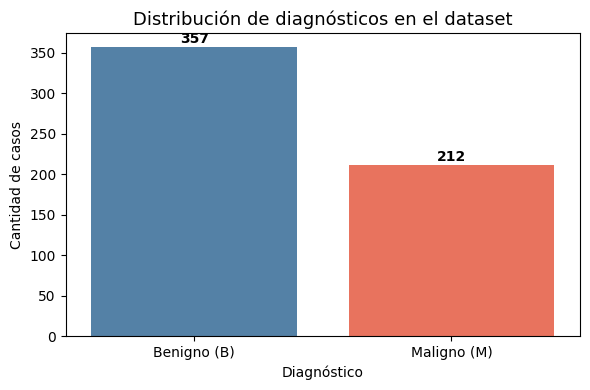

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_distribucion_diagnostico(df: pd.DataFrame) -> None:
    """Genera un gráfico de barras con la distribución de la variable objetivo."""
    conteo = df['diagnostico'].value_counts()
    etiquetas = ['Benigno (B)', 'Maligno (M)']

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=etiquetas, y=conteo.values, palette=['steelblue', 'tomato'], ax=ax)

    for i, v in enumerate(conteo.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

    ax.set_title('Distribución de diagnósticos en el dataset', fontsize=13)
    ax.set_xlabel('Diagnóstico')
    ax.set_ylabel('Cantidad de casos')
    plt.tight_layout()
    plt.show()

graficar_distribucion_diagnostico(df)

---
## 8. Conclusiones de la Fase 1

En esta primera fase se logró:

- **Definir la problemática** y la pregunta de investigación que guía el proyecto.
- **Configurar el entorno reproducible** con las librerías necesarias para las fases siguientes.
- **Cargar y explorar el dataset** Breast Cancer Wisconsin (Diagnostic), confirmando su estructura: 569 instancias, 30 variables morfológicas y una variable objetivo binaria sin valores faltantes.
- **Verificar la distribución de clases**: 357 casos benignos (62.7%) y 212 malignos (37.3%), lo que indica un dataset moderadamente balanceado.

### Proyección hacia fases siguientes
- **F2:** Preprocesamiento, limpieza, normalización y análisis exploratorio profundo.
- **F3:** Entrenamiento, evaluación e interpretación de modelos (Regresión Logística y Random Forest).

---
## Referencias

- Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1994). *Machine learning techniques to diagnose breast cancer from fine-needle aspirates*. Cancer Letters, 77, 163–171.
- UCI Machine Learning Repository. (1995). *Breast Cancer Wisconsin (Diagnostic)*. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Organización Mundial de la Salud. (2026). *Cáncer de mama*. https://www.who.int/es/news-room/fact-sheets/detail/breast-cancer